# Recall-Driven Curriculum Resampling (RDCR) for Rare-Lesion Diabetic Retinopathy
### MMRDR dataset -- UWF modality -- Kaggle-ready (single-GPU or dual-T4)

**Idea in one line:** every epoch, rebuild the training `WeightedRandomSampler` from the model's *current*
per-class validation **recall**, so the model automatically focuses on whichever grade/lesion classes it is
currently failing -- especially the rare, sight-threatening PDR lesions **NV, VH, RD**.

This notebook reuses the mature folder-3 pipeline (`UWF_SupConDRNet` + `AsymmetricFocalLoss` + SupCon + grade
CE) unchanged, and adds only the **sampler**, so any gain is attributable to the sampling strategy alone.

**How to run:** it executes top-to-bottom with no manual steps. The heavy training loop is gated behind
`CFG['RUN_TRAINING']` (default `False`); the sampler's core logic is verified by a CPU-only unit test that
always runs. Flip `RUN_TRAINING=True` on Kaggle with the MMRDR dataset attached to train for real.

**20 sections:** 1 Environment - 2 Configuration - 3 Imports - 4 Dataset Validation - 5 Dataset Statistics -
6 EDA - 7 Data Augmentation - 8 Model Architecture - 9 Loss Functions - 10 Optimizer - 11 Scheduler -
12 Metrics - (12b Dynamic Sampler + unit test) - 13 Training Loop - 14 Validation Loop - 15 Checkpoint Saving -
16 Resume Training - 17 Inference - 18 Error Analysis - 19 Visualization - 20 Future Improvements.

## 1. Environment Setup
Detect device and GPU count. On Kaggle with 2x T4 we later wrap the model in `nn.DataParallel`; on a single
GPU or CPU it degrades gracefully. Nothing here is Kaggle-specific -- it runs locally too.

In [15]:
import os, sys, platform
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
n_gpu = torch.cuda.device_count()
print(f"Python      : {sys.version.split()[0]} on {platform.system()}")
print(f"PyTorch     : {torch.__version__}")
print(f"Device      : {device}")
print(f"GPU count   : {n_gpu}")
if n_gpu:
    for i in range(n_gpu):
        print(f"  [{i}] {torch.cuda.get_device_name(i)}")
print(f"On Kaggle   : {os.path.isdir('/kaggle/input')}")

Python      : 3.12.13 on Linux
PyTorch     : 2.10.0+cu128
Device      : cuda
GPU count   : 2
  [0] Tesla T4
  [1] Tesla T4
On Kaggle   : True


## 2. Configuration (centralized config dict + seed fixing)
Every knob lives in one `CFG` dict so experiments/ablations change one place. The RDCR block maps directly to
the math in `RESEARCH_NOTES.md` Part B. `RUN_TRAINING=False` keeps the notebook fast and safe by default; the
unit test still runs. Reproducibility is enforced by `seed_everything`.

In [16]:
import random
import numpy as np

CFG = {
    # ---- data / pipeline (matches folder-3 exactly) ----
    'modality'      : 'UWF',
    'img_size'      : 512,
    'batch_size'    : 8,
    'num_workers'   : 2,
    'test_size'     : 0.2,
    'seed'          : 42,

    # ---- optimization ----
    'lr'            : 1e-4,
    'weight_decay'  : 1e-4,
    'epochs'        : 60,
    'patience'      : 10,          # early stopping on val loss
    'grad_clip'     : 2.0,
    'use_amp'       : True,

    # ---- RDCR sampler (see RESEARCH_NOTES.md Part B) ----
    'rdcr_enabled'  : True,        # False -> plain shuffle baseline (B0)
    'ema_m'         : 0.7,         # EMA momentum on the deficit
    'prior_a'       : 0.5,         # exponent on the static effective-number rarity prior (Cui 2019)
    'deficit_b'     : 1.0,         # exponent on the dynamic (1 - recall) deficit
    'eff_beta'      : 0.999,       # effective-number beta
    'eps'           : 1e-3,        # deficit floor
    't_warm'        : 5,           # curriculum: instance-balanced warmup epochs (Cao-DRW / Kang)
    't_ramp'        : 15,          # curriculum: epochs to ramp tau 0 -> 1
    'rho_max'       : 20.0,        # weight-ratio clamp (anti-overfit: caps rare-image repetition)
    'reduce'        : 'max',       # multi-label per-sample collapse: 'max' | 'sum' | 'mean' (Wu 2020)
    'use_ema'       : True,        # ablation A1
    'use_curriculum': True,        # ablation A2
    'stratify'      : True,        # stratified split on rare-lesion indicator (fixes repo weakness)

    # ---- run control ----
    'RUN_TRAINING'  : True,        # << flip to True on Kaggle GPU to actually train
    'RUN_FULL_EDA'  : True,
    'ckpt_dir'      : '/kaggle/working' if os.path.isdir('/kaggle/working') else '.',
    'resume_from'   : None,        # explicit checkpoint path; if None and RESUME=True, auto-find under /kaggle/input

    # ---- checkpoint backup to a Kaggle Dataset (survives idle-session restarts; /kaggle/working does NOT) ----
    'BACKUP_TO_DATASET'  : True,                           # auto-version checkpoints to a dataset during training
    'BACKUP_DATASET_SLUG': 'krrish1008/checkpoint-rdcr',   # SEPARATE slug from folder-4 so the two don't collide
    'BACKUP_EVERY'       : 2,                              # push every N epochs (also always pushes on a new best)
    'RESUME'             : True,                           # auto-resume from the newest checkpoint under /kaggle/input
}

# lesion channel names (fixed order, SHARED_CONTEXT sec.1)
LESION_NAMES = ['MA', 'HE', 'IH', 'VB/IRMA', 'NV', 'VH', 'RD']
RARE_LESION_IDX = [4, 5, 6]                 # NV, VH, RD define PDR
GRADE_NAMES = [f'Grade{g}' for g in range(5)]
# 12 unified rebalancing channels: 5 grade + 7 lesion
CHANNEL_NAMES = GRADE_NAMES + LESION_NAMES
NUM_CHANNELS = 12

def seed_everything(seed):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(CFG['seed'])
print("CFG loaded. RUN_TRAINING =", CFG['RUN_TRAINING'], "| RDCR enabled =", CFG['rdcr_enabled'])

CFG loaded. RUN_TRAINING = True | RDCR enabled = True


## 3. Imports
All third-party imports up front. `warnings` silenced for the undefined-metric noise that single-class
validation batches raise early in training.

In [17]:
import ast
import glob
import csv
import time, gc
import cv2
import pandas as pd
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from PIL import Image
import matplotlib.pyplot as plt
from torchvision import models, transforms
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, cohen_kappa_score, f1_score, roc_auc_score,
                             average_precision_score, balanced_accuracy_score,
                             matthews_corrcoef, recall_score, confusion_matrix)
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')
print("Imports OK.")

Imports OK.


## 4. Dataset Validation
**Glob-based autodetect** (per SHARED_CONTEXT sec.5): we search `/kaggle/input/**/UWF.csv` rather than
hardcoding a dataset slug -- the reference notebooks hardcode `krrish1008/mmrdr-dataset` but the actual
metadata slug is `krrish1008/my-mmrdr-dataset`, so a glob is robust to both. Falls back to a local `../MMRDR`
or `MMRDR` path. If nothing is found the notebook still runs (unit test, architecture, EDA on a stub) so it
never hard-crashes on a machine without the data.

In [18]:
def find_uwf_csv():
    # 1) Kaggle glob autodetect
    for pat in ['/kaggle/input/**/UWF.csv', '/kaggle/input/**/MMRDR-UWF/UWF.csv']:
        hits = glob.glob(pat, recursive=True)
        if hits:
            return hits[0]
    # 2) local fallbacks (repo layout)
    for cand in ['../MMRDR/MMRDR-UWF/UWF.csv',
                 'MMRDR/MMRDR-UWF/UWF.csv',
                 '../../MMRDR/MMRDR-UWF/UWF.csv']:
        if os.path.exists(cand):
            return cand
    return None

CSV_PATH = find_uwf_csv()
if CSV_PATH:
    IMG_DIR = os.path.dirname(CSV_PATH)          # UWF.csv 'image' field already includes 'img/' prefix
    print(f"[OK] Found UWF.csv at: {CSV_PATH}")
    print(f"     Image root      : {IMG_DIR}")
    DATA_AVAILABLE = True
else:
    IMG_DIR = None
    DATA_AVAILABLE = False
    print("[!] UWF.csv not found. Notebook will run in NO-DATA mode "
          "(unit test + architecture + loss checks still execute).")

[OK] Found UWF.csv at: /kaggle/input/datasets/krrish1008/mmrdr-dataset/MMRDR/MMRDR-UWF/UWF.csv
     Image root      : /kaggle/input/datasets/krrish1008/mmrdr-dataset/MMRDR/MMRDR-UWF


## 5. Dataset Statistics
Load the CSV, parse the 7-element lesion multi-hot vectors, and confirm the class distribution matches the
verified SHARED_CONTEXT numbers (UWF n=10,404; RD only 238 positives = 2.3%). These counts feed the
effective-number rarity prior. In NO-DATA mode we substitute the verified counts so the rest of the notebook
is still exercised.

In [19]:
def parse_lesion(s):
    s = str(s).strip().strip('[]')
    v = np.array([float(x) for x in s.split(',') if x.strip() != ''], dtype=np.float32)
    if v.shape[0] != 7:
        v = np.zeros(7, dtype=np.float32)
    return (v > 0).astype(np.float32)

# verified fallback counts (SHARED_CONTEXT sec.1, UWF)
VERIFIED_GRADE = {0:3372, 1:1936, 2:2166, 3:1377, 4:1553}
VERIFIED_LESION = {'MA':6938,'HE':3846,'IH':3849,'VB/IRMA':1010,'NV':1188,'VH':1219,'RD':238}

if DATA_AVAILABLE:
    df = pd.read_csv(CSV_PATH)
    df['lesion_vec'] = df['lesion'].apply(parse_lesion)
    grade_counts = df['grade'].value_counts().sort_index().to_dict()
    lesion_counts = {LESION_NAMES[j]: int(np.stack(df['lesion_vec'].values)[:, j].sum()) for j in range(7)}
    n_total = len(df)
else:
    df = None
    grade_counts = dict(VERIFIED_GRADE)
    lesion_counts = dict(VERIFIED_LESION)
    n_total = sum(VERIFIED_GRADE.values())

print(f"Total UWF images : {n_total}")
print("Grade counts     :", grade_counts)
print("Lesion positives :", lesion_counts)
print("Rare (NV/VH/RD)  :", {k: lesion_counts[k] for k in ['NV','VH','RD']})

Total UWF images : 10404
Grade counts     : {0: 3372, 1: 1936, 2: 2166, 3: 1377, 4: 1553}
Lesion positives : {'MA': 6938, 'HE': 3846, 'IH': 3848, 'VB/IRMA': 1010, 'NV': 1188, 'VH': 1219, 'RD': 238}
Rare (NV/VH/RD)  : {'NV': 1188, 'VH': 1219, 'RD': 238}


## 6. Exploratory Data Analysis
Two bars that motivate the whole method: the grade histogram (0 dominates) and the lesion-positive histogram
(RD is a sliver). The imbalance ratio (majority/minority) is what a *fixed* sampler must guess and freeze --
RDCR instead adapts it from validation recall.

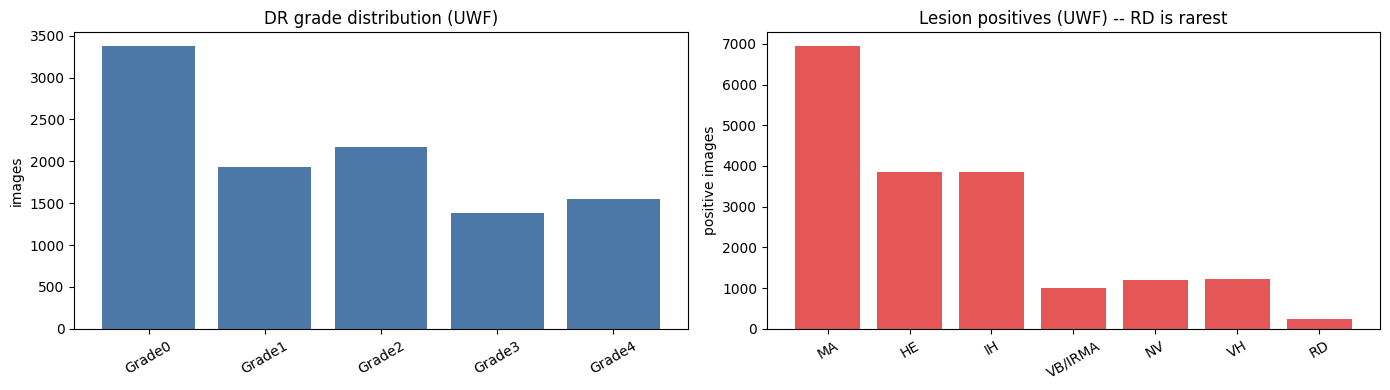

Grade imbalance ratio (max/min) : 2.4x
Lesion imbalance ratio (max/min): 29.2x   <- RD vs MA


In [20]:
if CFG['RUN_FULL_EDA']:
    fig, ax = plt.subplots(1, 2, figsize=(14, 4))
    ax[0].bar([GRADE_NAMES[g] for g in sorted(grade_counts)], [grade_counts[g] for g in sorted(grade_counts)],
              color='#4C78A8')
    ax[0].set_title('DR grade distribution (UWF)'); ax[0].set_ylabel('images')
    order = LESION_NAMES
    ax[1].bar(order, [lesion_counts[k] for k in order], color='#E45756')
    ax[1].set_title('Lesion positives (UWF) -- RD is rarest'); ax[1].set_ylabel('positive images')
    for a in ax: a.tick_params(axis='x', rotation=30)
    plt.tight_layout(); plt.show()

    imb_grade = max(grade_counts.values())/min(grade_counts.values())
    imb_lesion = max(lesion_counts.values())/min(lesion_counts.values())
    print(f"Grade imbalance ratio (max/min) : {imb_grade:.1f}x")
    print(f"Lesion imbalance ratio (max/min): {imb_lesion:.1f}x   <- RD vs MA")

## 7. Data Augmentation
Reused from folder 3 (flips, mild rotation, colour jitter, ImageNet normalization). Augmentation is RDCR's
**primary defense against oversampling overfitting**: because rare images get drawn many times, they must
look different on each draw. `apply_uwf_mask` (elliptical crop of eyelid/eyelash artifacts) is applied *before*
the tensor transforms, and images are resized to 512 *before* cv2 masking so the CPU does not bottleneck the
GPU (folder-3 performance tip).

In [21]:
def apply_uwf_mask(pil_img, tightness=0.98):
    img = np.array(pil_img)
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    _, thresh = cv2.threshold(gray, 15, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return pil_img
    largest = max(contours, key=cv2.contourArea)
    if len(largest) >= 5:
        e = cv2.fitEllipse(largest)
        se = (e[0], (e[1][0]*tightness, e[1][1]*tightness), e[2])
        mask = np.zeros_like(gray)
        cv2.ellipse(mask, se, 255, -1)
        return Image.fromarray(cv2.bitwise_and(img, img, mask=mask))
    return pil_img

IMAGENET_MEAN = [0.485, 0.456, 0.406]; IMAGENET_STD = [0.229, 0.224, 0.225]
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.RandomRotation(degrees=10),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])
val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])
print("Transforms + apply_uwf_mask ready.")

Transforms + apply_uwf_mask ready.


### Dataset class + stratified split + per-sample channel memberships
`UWF_Dataset` matches folder 3 and additionally returns the sample index so we can trace which images the
sampler favours. We build the **stratified split on the rare-lesion indicator** (fixes the repo's
non-stratified split) and precompute, for each training image, its **membership set** `C(i)` = its grade
channel plus its positive lesion channels -- this is what the sampler collapses into a per-sample weight.

In [22]:
class UWF_Dataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        # Pre-extract to numpy arrays instead of keeping the DataFrame and calling df.iloc[idx] per
        # item: under num_workers>0, per-row pandas access bumps Python refcounts on copy-on-write
        # pages, so each forked worker's RAM creeps up over epochs (the DataLoader "leak", #13246).
        self.img_dir = img_dir
        self.transform = transform
        self.paths = df['image'].to_numpy()                                          # str paths
        self.grades = df['grade'].to_numpy().astype(np.int64)                         # [N]
        self.lesions = np.stack([parse_lesion(x) for x in df['lesion'].values]).astype(np.float32)  # [N,7]
    def __len__(self):
        return len(self.paths)
    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.paths[idx]) if self.img_dir else ''
        if (not self.img_dir) or (not os.path.exists(img_path)):
            image = Image.new('RGB', (512, 512), (0, 0, 0))          # graceful stub
        else:
            image = Image.open(img_path).convert('RGB').resize((512, 512), Image.Resampling.BILINEAR)
        image = apply_uwf_mask(image)
        if self.transform:
            image = self.transform(image)
        les = self.lesions[idx]
        has_rare = 1.0 if les[RARE_LESION_IDX].sum() > 0 else 0.0
        return image, int(self.grades[idx]), torch.from_numpy(les.copy()), torch.tensor(has_rare, dtype=torch.float32), idx

def build_memberships(frame):
    '''C(i) = [grade channel] + [5 + lesion_idx for each positive lesion].'''
    mem = []
    for _, row in frame.iterrows():
        ch = [int(row['grade'])]
        lv = parse_lesion(row['lesion'])
        ch += [5 + j for j in range(7) if lv[j] > 0]
        mem.append(ch)
    return mem

def channel_counts(frame):
    '''n_k over the 12 channels from the TRAIN split (feeds the effective-number prior).'''
    counts = np.zeros(NUM_CHANNELS, dtype=np.float64)
    gc = frame['grade'].value_counts().to_dict()
    for g in range(5):
        counts[g] = gc.get(g, 0)
    lv = np.stack([parse_lesion(x) for x in frame['lesion'].values])
    for j in range(7):
        counts[5 + j] = lv[:, j].sum()
    return counts

if DATA_AVAILABLE:
    strat = None
    if CFG['stratify']:
        strat = df['lesion'].apply(lambda s: 1 if parse_lesion(s)[RARE_LESION_IDX].sum() > 0 else 0)
    train_df, val_df = train_test_split(df, test_size=CFG['test_size'], random_state=CFG['seed'],
                                        stratify=strat)
    train_mem = build_memberships(train_df)
    train_counts = channel_counts(train_df)
    print(f"Split -> train {len(train_df)} | val {len(val_df)} | stratified={CFG['stratify']}")
    print("Train channel counts (5 grade + 7 lesion):", train_counts.astype(int).tolist())
else:
    train_df = val_df = None
    train_mem = None
    train_counts = np.array([grade_counts.get(g,0) for g in range(5)] +
                            [lesion_counts[n] for n in LESION_NAMES], dtype=np.float64)
    print("NO-DATA mode: using verified channel counts:", train_counts.astype(int).tolist())

Split -> train 8323 | val 2081 | stratified=True
Train channel counts (5 grade + 7 lesion): [2702, 1558, 1738, 1083, 1242, 5544, 3052, 3073, 819, 957, 976, 193]


## 8. Model Architecture -- `UWF_SupConDRNet` (reused from folder 3, unchanged)
ResNet-50 backbone -> FPN classifier (lateral 1x1 convs on l1-l4 + top-down fusion) -> lesion head (7) and
grade head (5), plus two SupCon projection heads (`proj_early` on layer2, `proj_deep` on layer4). Chosen
because it is the repo's mature, fully-trained baseline -- keeping the backbone fixed makes the sampler the
**only** independent variable. (RETFound too heavy for T4; ViT/Swin data-hungry at 512px; EfficientNet viable
but breaks continuity -- see IMPLEMENTATION_GUIDE.md sec.1.)

In [23]:
class UWF_SupConDRNet(nn.Module):
    def __init__(self):
        super().__init__()
        resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
        self.stem = nn.Sequential(resnet.conv1, resnet.bn1, resnet.relu, resnet.maxpool)
        self.layer1, self.layer2 = resnet.layer1, resnet.layer2
        self.layer3, self.layer4 = resnet.layer3, resnet.layer4
        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.proj_early = nn.Sequential(nn.Linear(512, 512), nn.ReLU(), nn.Linear(512, 128))
        self.proj_deep  = nn.Sequential(nn.Linear(2048, 512), nn.ReLU(), nn.Linear(512, 128))
        self.lat_l4 = nn.Conv2d(2048, 512, 1); self.lat_l3 = nn.Conv2d(1024, 512, 1)
        self.lat_l2 = nn.Conv2d(512, 512, 1);  self.lat_l1 = nn.Conv2d(256, 512, 1)
        self.classifier_lesions = nn.Linear(512, 7)
        self.classifier_grade   = nn.Linear(512, 5)
    def forward(self, x):
        x = self.stem(x)
        l1 = self.layer1(x); l2 = self.layer2(l1); l3 = self.layer3(l2); l4 = self.layer4(l3)
        z_early = self.proj_early(self.global_pool(l2).flatten(1))
        z_deep  = self.proj_deep(self.global_pool(l4).flatten(1))
        p4 = self.lat_l4(l4)
        p3 = self.lat_l3(l3) + F.interpolate(p4, size=l3.shape[-2:], mode='bilinear', align_corners=False)
        p2 = self.lat_l2(l2) + F.interpolate(p3, size=l2.shape[-2:], mode='bilinear', align_corners=False)
        p1 = self.lat_l1(l1) + F.interpolate(p2, size=l1.shape[-2:], mode='bilinear', align_corners=False)
        pooled = self.global_pool(p1).flatten(1)
        return self.classifier_lesions(pooled), self.classifier_grade(pooled), z_early, z_deep

def build_model():
    m = UWF_SupConDRNet()
    if torch.cuda.device_count() > 1:
        print(f"Wrapping model in DataParallel across {torch.cuda.device_count()} GPUs.")
        m = nn.DataParallel(m)
    return m.to(device)

# quick shape sanity on a single dummy image (CPU-safe)
_m = UWF_SupConDRNet().eval()
with torch.no_grad():
    ol, og, ze, zd = _m(torch.randn(1, 3, 512, 512))
print(f"Forward OK -> lesions {tuple(ol.shape)} grade {tuple(og.shape)} z_early {tuple(ze.shape)}")
del _m

Forward OK -> lesions (1, 7) grade (1, 5) z_early (1, 128)


## 9. Loss Functions -- reused from folder 3
`AsymmetricFocalLoss` (per-class beta `[.7,.7,.7,.8,.95,.95,.95]` -- penalizes false negatives on PDR lesions
harder than false positives), `SupConLoss` (supervised contrastive on the rare-lesion flag), and grade
`CrossEntropyLoss`. Combined objective (folder-3 convergence point):
`loss = asym_lesion + CE_grade + 0.5*supcon_early + 0.5*supcon_deep`.

RDCR keeps this loss untouched -- resampling changes *what enters the batch*, the loss changes *how much each
sample counts*. They are complementary (Lin 2017 focal is the re-weighting cousin of resampling).

In [24]:
class AsymmetricFocalLoss(nn.Module):
    def __init__(self, gamma=2.0):
        super().__init__()
        self.gamma = gamma
        self.beta = torch.tensor([0.7, 0.7, 0.7, 0.8, 0.95, 0.95, 0.95], device=device)
    def forward(self, logits, targets):
        bce = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        pt = torch.exp(-bce)
        focal = (1 - pt) ** self.gamma * bce
        return torch.where(targets == 1, self.beta * focal, (1 - self.beta) * focal).mean()

class SupConLoss(nn.Module):
    def __init__(self, temperature=0.1):
        super().__init__()
        self.temperature = temperature
    def forward(self, features, labels):
        features = F.normalize(features, dim=1)
        sim = torch.matmul(features, features.T) / self.temperature
        sim = sim - sim.max(dim=1, keepdim=True)[0].detach()
        labels = labels.contiguous().view(-1, 1)
        mask = torch.eq(labels, labels.T).float().to(features.device)
        self_mask = torch.scatter(torch.ones_like(mask), 1,
                                  torch.arange(features.shape[0], device=features.device).view(-1, 1), 0)
        mask = mask * self_mask
        exp_logits = torch.exp(sim) * self_mask
        log_prob = sim - torch.log(exp_logits.sum(1, keepdim=True) + 1e-8)
        denom = mask.sum(1); denom = torch.where(denom == 0, torch.ones_like(denom), denom)
        return (-(mask * log_prob).sum(1) / denom).mean()

criterion_lesions = AsymmetricFocalLoss(gamma=2.0)
criterion_supcon  = SupConLoss(temperature=0.1)
criterion_grade   = nn.CrossEntropyLoss()
print("Losses ready: AsymmetricFocalLoss + SupConLoss + grade CrossEntropy.")

Losses ready: AsymmetricFocalLoss + SupConLoss + grade CrossEntropy.


## 10. Optimizer
AdamW (lr 1e-4, weight_decay 1e-4) -- folder-3 values. Weight decay is one of our kept regularizers.

In [25]:
def build_optimizer(model):
    return optim.AdamW(model.parameters(), lr=CFG['lr'], weight_decay=CFG['weight_decay'])
print("Optimizer factory ready (AdamW).")

Optimizer factory ready (AdamW).


## 11. Scheduler
`ReduceLROnPlateau` on validation loss (factor 0.5, patience 3) -- folder-3 value; stabilizes the late
curriculum ramp when the sampler shifts the effective data distribution.

In [26]:
def build_scheduler(optimizer):
    return optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
print("Scheduler factory ready (ReduceLROnPlateau).")

Scheduler factory ready (ReduceLROnPlateau).


## 12. Metrics (clinical set -- SHARED_CONTEXT sec.8)
Two functions:
- `calculate_metrics` -- the compact folder-3 quartet (grade acc, **quadratic-weighted Kappa**, lesion macro-F1,
  macro-AUROC) for the training log.
- `clinical_report` -- the full clinical set for evaluation: grade balanced-accuracy, per-class recall, MCC,
  confusion matrix; lesion per-class + macro **AUROC** and **PR-AUC** (PR-AUC is the honest metric under heavy
  negative dominance -- emphasized for RD/NV/VH), per-class **recall (headline)**, macro-F1.
- `recall_vector` -- the 12-channel recall (5 grade + 7 lesion) that drives the sampler.

In [27]:
def calculate_metrics(gp, gt, lp, lt):
    acc = accuracy_score(gt, gp)
    kappa = cohen_kappa_score(gt, gp, weights='quadratic')
    lp = np.array(lp); ltb = (np.array(lt) > 0.5).astype(int)
    f1 = f1_score(ltb, (lp > 0.5).astype(int), average='macro', zero_division=0)
    try:
        auc = roc_auc_score(ltb, lp, average='macro')
    except ValueError:
        auc = 0.0
    return acc, kappa, f1, auc

def recall_vector(gp, gt, lp, lt):
    '''12-vector: grade one-vs-rest recall (0..4) then lesion positive recall (0..6).'''
    out = np.zeros(NUM_CHANNELS, dtype=np.float64)
    gp, gt = np.array(gp), np.array(gt)
    gr = recall_score(gt, gp, labels=list(range(5)), average=None, zero_division=0)
    out[:5] = gr
    lp = (np.array(lp) > 0.5).astype(int); ltb = (np.array(lt) > 0.5).astype(int)
    for j in range(7):
        tp = int(((lp[:, j] == 1) & (ltb[:, j] == 1)).sum())
        pos = int((ltb[:, j] == 1).sum())
        out[5 + j] = tp / pos if pos > 0 else 1.0     # no positives -> treat as satisfied
    return out

def clinical_report(gp, gt, lp, lt):
    gp, gt = np.array(gp), np.array(gt)
    lp = np.array(lp); ltb = (np.array(lt) > 0.5).astype(int)
    rep = {}
    rep['grade_acc']       = accuracy_score(gt, gp)
    rep['grade_bal_acc']   = balanced_accuracy_score(gt, gp)
    rep['grade_kappa_qw']  = cohen_kappa_score(gt, gp, weights='quadratic')
    rep['grade_mcc']       = matthews_corrcoef(gt, gp) if len(np.unique(gt)) > 1 else 0.0
    rep['grade_recall']    = recall_score(gt, gp, labels=list(range(5)), average=None, zero_division=0).tolist()
    per_auc, per_ap, per_rec = {}, {}, {}
    for j, name in enumerate(LESION_NAMES):
        yj, pj = ltb[:, j], lp[:, j]
        try:    per_auc[name] = roc_auc_score(yj, pj) if len(np.unique(yj)) > 1 else float('nan')
        except ValueError: per_auc[name] = float('nan')
        try:    per_ap[name]  = average_precision_score(yj, pj) if yj.sum() > 0 else float('nan')
        except ValueError: per_ap[name]  = float('nan')
        pred = (pj > 0.5).astype(int)
        per_rec[name] = (int(((pred == 1) & (yj == 1)).sum()) / int(yj.sum())) if yj.sum() > 0 else float('nan')
    rep['lesion_auroc'] = per_auc
    rep['lesion_prauc'] = per_ap
    rep['lesion_recall'] = per_rec
    rep['lesion_macro_f1'] = f1_score(ltb, (lp > 0.5).astype(int), average='macro', zero_division=0)
    rep['rare_recall_headline'] = {LESION_NAMES[k]: per_rec[LESION_NAMES[k]] for k in RARE_LESION_IDX}
    return rep
print("Metric functions ready.")

Metric functions ready.


## 12b. Dynamic Recall-Driven Sampler (the core contribution) + CPU unit test
`RecallDrivenSampler` implements RESEARCH_NOTES.md Part B exactly:
1. static effective-number rarity prior (Cui 2019), normalized to mean 1;
2. EMA of the per-class deficit `D = m*D + (1-m)*(1-recall)`;
3. per-class importance `I = prior^a * (D+eps)^b`;
4. per-sample collapse over its channels (`max` default -- avoids double-counting co-occurring PDR lesions,
   Wu 2020);
5. curriculum temperature `s_hat = s^tau(epoch)` (uniform during warmup, ramps to recall-driven);
6. clamp weight ratio to `rho_max` and normalize.

Its state (`D`) is checkpointed so resume continues the controller. **The unit test below runs on CPU with
tiny synthetic data and asserts the sampler up-weights a deliberately-starved rare class** -- this is our
folder-2-style dummy-data guarantee that the mechanism is correct even without the GPU training run.

In [28]:
class RecallDrivenSampler:
    def __init__(self, memberships, class_counts, cfg):
        self.mem = memberships
        self.N = len(memberships)
        self.K = NUM_CHANNELS
        self.m = cfg['ema_m']; self.a = cfg['prior_a']; self.b = cfg['deficit_b']
        self.eps = cfg['eps']; self.t_warm = cfg['t_warm']; self.t_ramp = cfg['t_ramp']
        self.rho_max = cfg['rho_max']; self.reduce = cfg['reduce']
        self.use_ema = cfg['use_ema']; self.use_curriculum = cfg['use_curriculum']
        n = np.maximum(np.asarray(class_counts, dtype=np.float64), 1.0)
        eff = (1.0 - cfg['eff_beta']) / (1.0 - np.power(cfg['eff_beta'], n))   # effective number (Cui 2019)
        self.prior = eff / eff.mean()
        self.D = np.ones(self.K, dtype=np.float64)                            # max deficit at init
        # precompute a sparse membership matrix for vectorized collapse
        self._rows = np.array([i for i, ch in enumerate(memberships) for _ in ch])
        self._cols = np.array([c for ch in memberships for c in ch])

    def update(self, recall):
        d = 1.0 - np.clip(np.asarray(recall, dtype=np.float64), 0.0, 1.0)
        self.D = (self.m * self.D + (1 - self.m) * d) if self.use_ema else d

    def class_importance(self):
        return (self.prior ** self.a) * (self.D + self.eps) ** self.b

    def tau(self, epoch):
        if not self.use_curriculum:
            return 1.0
        if epoch < self.t_warm:
            return 0.0
        if self.t_ramp <= 0:
            return 1.0
        return float(np.clip((epoch - self.t_warm) / self.t_ramp, 0.0, 1.0))

    def sample_weights(self, epoch):
        I = self.class_importance()
        vals = I[self._cols]
        s = np.ones(self.N, dtype=np.float64)
        if self.reduce == 'sum':
            s = np.zeros(self.N); np.add.at(s, self._rows, vals); s[s == 0] = 1.0
        elif self.reduce == 'mean':
            tot = np.zeros(self.N); cnt = np.zeros(self.N)
            np.add.at(tot, self._rows, vals); np.add.at(cnt, self._rows, 1.0)
            s = np.where(cnt > 0, tot / np.maximum(cnt, 1), 1.0)
        else:  # 'max'
            # init to zeros (not ones): with a ones init, np.maximum floors every
            # per-sample weight at 1.0, which wipes out any importance < 1 (the prior is
            # mean-normalized, so importances routinely sit below 1) and silently collapses
            # the sampler to uniform. Zeros is the correct identity for a max-reduction;
            # samples with empty membership (never happens in practice -- every sample has a
            # grade channel) fall back to the neutral 1.0, matching the 'sum'/'mean' branches.
            s = np.zeros(self.N)
            np.maximum.at(s, self._rows, vals)
            s[s == 0] = 1.0
        s = np.power(np.maximum(s, 1e-12), self.tau(epoch))    # curriculum temperature
        s = s / s.mean()                                        # normalize to mean 1
        s = np.clip(s, 1.0 / self.rho_max, self.rho_max)        # anti-overfit ratio clamp
        return s

    def build_sampler(self, epoch, generator=None):
        w = torch.as_tensor(self.sample_weights(epoch), dtype=torch.double)
        return WeightedRandomSampler(w, num_samples=self.N, replacement=True, generator=generator)

    def state_dict(self):
        return {'D': self.D.tolist()}
    def load_state_dict(self, st):
        self.D = np.asarray(st['D'], dtype=np.float64)


# ------------------------------- CPU-ONLY UNIT TEST (always runs) -------------------------------
def _unit_test_sampler():
    # 100 synthetic samples: 90 in common channel 0, 10 in rare channel 5 (a lesion channel)
    mem = [[0]] * 90 + [[5]] * 10
    counts = np.array([90, 1, 1, 1, 1, 10, 1, 1, 1, 1, 1, 1], dtype=np.float64)
    tcfg = dict(CFG); tcfg.update(t_warm=0, t_ramp=1)     # skip warmup so tau=1 quickly
    s = RecallDrivenSampler(mem, counts, tcfg)

    # (a) during warmup (epoch<t_warm with curriculum) weights are uniform
    warm_cfg = dict(CFG); warm_cfg.update(t_warm=5, t_ramp=15)
    sw = RecallDrivenSampler(mem, counts, warm_cfg)
    w0 = sw.sample_weights(epoch=0)
    assert np.allclose(w0, w0[0]), "Warmup must be uniform (tau=0)."

    # (b) model is great on common (recall .99) but blind on rare (recall .05) -> rare up-weighted
    rec = np.full(12, 0.99); rec[5] = 0.05
    s.update(rec)
    w = s.sample_weights(epoch=5)                          # tau=1
    rare_w, common_w = w[90:].mean(), w[:90].mean()
    assert rare_w > common_w, f"Rare class must be up-weighted ({rare_w:.3f} !> {common_w:.3f})."

    # (c) actually drawing over-samples the rare class beyond its natural 10%
    gen = torch.Generator().manual_seed(0)
    draws = list(s.build_sampler(epoch=5, generator=gen))
    rare_frac = sum(1 for d in draws if d >= 90) / len(draws)
    assert rare_frac > 0.10, f"Rare draw fraction {rare_frac:.2f} should exceed natural 0.10."

    # (d) clamp respected
    assert w.max() <= CFG['rho_max'] + 1e-6 and w.min() >= 1.0/CFG['rho_max'] - 1e-6, "Clamp violated."

    print(f"[unit test] PASS | warmup uniform, rare up-weighted ({rare_w:.2f} vs {common_w:.2f}), "
          f"rare draw frac {rare_frac:.2f} (natural 0.10), clamp OK.")

_unit_test_sampler()

[unit test] PASS | warmup uniform, rare up-weighted (3.14 vs 0.76), rare draw frac 0.26 (natural 0.10), clamp OK.


## 13. Training Loop (gated behind `CFG['RUN_TRAINING']`)
Per epoch: (1) build the sampler from the previous epoch's EMA deficit + curriculum tau; (2) train with AMP,
gradient clipping, and the folder-3 combined loss; (3) run the validation loop (Section 14); (4)
`rdcr.update(recall)` for the next epoch; (5) step the scheduler, checkpoint, and log to CSV. If
`rdcr_enabled` is False this reduces to the plain-shuffle **baseline B0**. Everything is wrapped so that with
`RUN_TRAINING=False` the notebook simply prints a skip message and moves on.

In [29]:
from torch.amp import GradScaler, autocast

def run_one_epoch(model, loader, optimizer, scaler, train=True):
    model.train() if train else model.eval()
    total_loss = 0.0
    gp, gt, lp, lt = [], [], [], []
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for images, grades, lesions, rare, _ in tqdm(loader, desc='train' if train else 'val', leave=False):
            images = images.to(device, non_blocking=True); grades = grades.to(device, non_blocking=True)
            lesions = lesions.to(device, non_blocking=True); rare = rare.to(device, non_blocking=True)
            if train: optimizer.zero_grad()
            with autocast(device_type=device.type, enabled=CFG['use_amp']):
                ol, og, ze, zd = model(images)
                loss = (criterion_lesions(ol, lesions) + criterion_grade(og, grades)
                        + 0.5 * criterion_supcon(ze, rare) + 0.5 * criterion_supcon(zd, rare))
            if train:
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), CFG['grad_clip'])
                scaler.step(optimizer); scaler.update()
            total_loss += loss.item() * images.size(0)
            gp.extend(torch.argmax(og, 1).detach().cpu().numpy()); gt.extend(grades.cpu().numpy())
            lp.extend(torch.sigmoid(ol).detach().cpu().numpy()); lt.extend(lesions.cpu().numpy())
    return total_loss / len(loader.dataset), gp, gt, lp, lt


def train_rdcr():
    seed_everything(CFG['seed'])
    model = build_model()
    optimizer = build_optimizer(model); scheduler = build_scheduler(optimizer)
    scaler = GradScaler(enabled=CFG['use_amp'])
    rdcr = RecallDrivenSampler(train_mem, train_counts, CFG) if CFG['rdcr_enabled'] else None
    gen = torch.Generator().manual_seed(CFG['seed'])

    val_loader = DataLoader(UWF_Dataset(val_df, IMG_DIR, val_transform), batch_size=CFG['batch_size'],
                            shuffle=False, num_workers=CFG['num_workers'], pin_memory=True,
                            persistent_workers=False)

    start_epoch, best_val = 0, float('inf'); patience = 0
    ckpt = os.path.join(CFG['ckpt_dir'], 'checkpoint.pth')
    resume_path = CFG['resume_from'] or (find_resume_checkpoint() if CFG.get('RESUME') else None)
    if resume_path:
        start_epoch, best_val = load_checkpoint(resume_path, model, optimizer, scheduler, rdcr)

    log_path = os.path.join(CFG['ckpt_dir'], 'metrics_log.csv')
    with open(log_path, 'a', newline='') as f:
        if os.stat(log_path).st_size == 0:
            csv.writer(f).writerow(['epoch','tau','train_loss','val_loss','val_kappa','val_lesion_auc',
                                    'val_lesion_f1','rare_recall_NV','rare_recall_VH','rare_recall_RD'])

    for epoch in range(start_epoch, CFG['epochs']):
        train_ds = UWF_Dataset(train_df, IMG_DIR, train_transform)
        if rdcr is not None:
            sampler = rdcr.build_sampler(epoch, generator=gen)
            train_loader = DataLoader(train_ds, batch_size=CFG['batch_size'], sampler=sampler,
                                      num_workers=CFG['num_workers'], pin_memory=True,
                                      persistent_workers=False)
            tau = rdcr.tau(epoch)
        else:
            train_loader = DataLoader(train_ds, batch_size=CFG['batch_size'], shuffle=True,
                                      num_workers=CFG['num_workers'], pin_memory=True,
                                      persistent_workers=False)
            tau = float('nan')

        cur_lr = optimizer.param_groups[0]['lr']
        t0 = time.time()
        tr_loss, *_ = run_one_epoch(model, train_loader, optimizer, scaler, train=True)
        val_loss, gp, gt, lp, lt = run_one_epoch(model, val_loader, optimizer, scaler, train=False)
        elapsed = time.time() - t0

        acc, kappa, f1, auc = calculate_metrics(gp, gt, lp, lt)
        rec12 = recall_vector(gp, gt, lp, lt)
        rep = clinical_report(gp, gt, lp, lt)
        macro_prauc = float(np.nanmean(list(rep['lesion_prauc'].values())))

        is_best = val_loss < best_val
        if is_best: best_val, patience = val_loss, 0
        else: patience += 1

        # ---- clean per-epoch summary block ----
        fmt = lambda v: f"{v:.2f}" if v == v else "n/a"        # v==v is False only for NaN
        hl = rep['rare_recall_headline']
        star = "   <-- NEW BEST" if is_best else ""
        print(f"\nEpoch {epoch+1:02d}/{CFG['epochs']}  |  tau {tau:.2f}  |  lr {cur_lr:.1e}  |  {elapsed:.0f}s{star}")
        print(f"   loss    train {tr_loss:.4f}   val {val_loss:.4f}   (best {best_val:.4f}, patience {patience}/{CFG['patience']})")
        print(f"   grade   kappa {kappa:.4f}   acc {acc:.3f}")
        print(f"   lesion  macro-F1 {f1:.3f}   AUC {auc:.3f}   PR-AUC {macro_prauc:.3f}")
        print(f"   rare    NV {fmt(hl['NV'])}   VH {fmt(hl['VH'])}   RD {fmt(hl['RD'])}   (recall, headline)")

        if rdcr is not None:
            rdcr.update(rec12)                                  # feed controller for NEXT epoch
        scheduler.step(val_loss)

        save_checkpoint({'epoch': epoch + 1, 'state_dict': model.state_dict(),
                         'optimizer': optimizer.state_dict(), 'scheduler': scheduler.state_dict(),
                         'best_loss': best_val,
                         'rdcr_state': rdcr.state_dict() if rdcr is not None else None},
                        is_best, filename=ckpt,
                        best_filename=os.path.join(CFG['ckpt_dir'], 'best_model.pth'))
        with open(log_path, 'a', newline='') as f:
            csv.writer(f).writerow([epoch+1, f"{tau:.3f}", f"{tr_loss:.4f}", f"{val_loss:.4f}",
                                    f"{kappa:.4f}", f"{auc:.4f}", f"{f1:.4f}",
                                    hl['NV'], hl['VH'], hl['RD']])
        # back the checkpoint up to a Kaggle Dataset so it survives an idle-session restart
        if CFG['BACKUP_TO_DATASET'] and ((epoch+1) % CFG['BACKUP_EVERY'] == 0 or is_best):
            push_to_dataset(reason=f"epoch {epoch+1} val {val_loss:.4f}")
        gc.collect(); torch.cuda.empty_cache()                  # release per-epoch host/GPU scratch
        if patience >= CFG['patience']:
            print("Early stopping."); break
    if CFG['BACKUP_TO_DATASET']:
        push_to_dataset(reason='final')                         # final backup on normal/early-stop exit
    return model

print("train_rdcr ready (the gated call runs after the checkpoint/resume cells are defined).")

train_rdcr ready (the gated call runs after the checkpoint/resume cells are defined).


## 14. Validation Loop
Validation is `run_one_epoch(..., train=False)` (used inside training) plus a standalone `evaluate` that
prints the **full clinical report** (Section 12) -- the per-rare-class recall headline, per-class PR-AUC, grade
quadratic Kappa, confusion matrix -- on demand from any checkpoint.

In [30]:
def evaluate(model, loader):
    _, gp, gt, lp, lt = run_one_epoch(model, loader, optimizer=None, scaler=GradScaler(enabled=False),
                                      train=False)
    rep = clinical_report(gp, gt, lp, lt)
    print("=== Clinical report ===")
    print(f"Grade: acc {rep['grade_acc']:.3f} | bal_acc {rep['grade_bal_acc']:.3f} | "
          f"quadratic-Kappa {rep['grade_kappa_qw']:.3f} | MCC {rep['grade_mcc']:.3f}")
    print("Grade per-class recall:", [f'{r:.2f}' for r in rep['grade_recall']])
    print("Lesion PR-AUC :", {k: (f'{v:.2f}' if v==v else 'n/a') for k,v in rep['lesion_prauc'].items()})
    print("Lesion recall :", {k: (f'{v:.2f}' if v==v else 'n/a') for k,v in rep['lesion_recall'].items()})
    print("HEADLINE rare-class recall (NV/VH/RD):", rep['rare_recall_headline'])
    return rep, (gp, gt, lp, lt)

print("evaluate() ready (call on a loaded checkpoint).")

evaluate() ready (call on a loaded checkpoint).


## 15. Checkpoint Saving (+ backup to a Kaggle Dataset)
Folder-3 `save_checkpoint` extended with `rdcr_state` (the EMA deficit vector `D`) so a resumed run continues
the controller and curriculum rather than restarting them. Saves per-epoch `checkpoint.pth` and best-by-val-loss
`best_model.pth` to `/kaggle/working`.

**Important:** `/kaggle/working` is **wiped when an interactive kernel idles out**. `push_to_dataset`
(gated behind `CFG['BACKUP_TO_DATASET']`) versions the saved files into a Kaggle **Dataset** so they persist
across sessions; the training loop calls it every `BACKUP_EVERY` epochs and on each new best. It needs Kaggle
API credentials: add `KAGGLE_USERNAME` + `KAGGLE_KEY` as notebook **Secrets** (Add-ons > Secrets). Uses a
**separate** dataset slug (`checkpoint-rdcr`) from folder 4 so the two experiments' checkpoints don't mix.

In [31]:
def save_checkpoint(state, is_best, filename='checkpoint.pth', best_filename='best_model.pth'):
    torch.save(state, filename)
    if is_best:
        torch.save(state, best_filename)
        print(f"  [*] new best -> {best_filename}")
print("save_checkpoint ready.")

import json, shutil, subprocess

def ensure_kaggle_auth():
    '''Authenticate the kaggle CLI WITHOUT hard-coding the key. Priority: ~/.kaggle/kaggle.json >
    env vars > Kaggle Secrets. On Kaggle add two Secrets named KAGGLE_USERNAME and KAGGLE_KEY
    (Add-ons > Secrets); they get bridged into env vars here.'''
    if os.path.exists(os.path.expanduser('~/.kaggle/kaggle.json')):
        return True
    if os.environ.get('KAGGLE_USERNAME') and os.environ.get('KAGGLE_KEY'):
        return True
    try:
        from kaggle_secrets import UserSecretsClient
        us = UserSecretsClient()
        os.environ['KAGGLE_USERNAME'] = us.get_secret('KAGGLE_USERNAME')
        os.environ['KAGGLE_KEY'] = us.get_secret('KAGGLE_KEY')
        return True
    except Exception as e:
        print('   [backup] no Kaggle creds - add KAGGLE_USERNAME + KAGGLE_KEY as Secrets:', str(e)[:120])
        return False

def push_to_dataset(reason=''):
    '''Version checkpoint.pth / best_model.pth / metrics_log.csv into a Kaggle Dataset so they survive
    an idle-session restart. No-op unless CFG['BACKUP_TO_DATASET']. Failures are non-fatal.'''
    if not CFG.get('BACKUP_TO_DATASET'):
        return
    if not ensure_kaggle_auth():
        return
    slug = CFG['BACKUP_DATASET_SLUG']
    workdir = os.path.join(CFG['ckpt_dir'], 'ckpt_backup')
    os.makedirs(workdir, exist_ok=True)
    staged = 0
    for name in ('checkpoint.pth', 'best_model.pth', 'metrics_log.csv'):
        src = os.path.join(CFG['ckpt_dir'], name)
        if os.path.exists(src):
            shutil.copy(src, os.path.join(workdir, name)); staged += 1
    if staged == 0:
        print('   [backup] nothing to push yet'); return
    with open(os.path.join(workdir, 'dataset-metadata.json'), 'w') as fh:
        json.dump({'title': slug.split('/')[-1], 'id': slug, 'licenses': [{'name': 'CC0-1.0'}]}, fh)
    ver = subprocess.run(['kaggle', 'datasets', 'version', '-p', workdir, '-m', reason or 'auto',
                          '--dir-mode', 'zip'], capture_output=True, text=True)
    if ver.returncode != 0:
        crt = subprocess.run(['kaggle', 'datasets', 'create', '-p', workdir, '--dir-mode', 'zip'],
                             capture_output=True, text=True)
        ok, out = crt.returncode == 0, (crt.stdout or crt.stderr)
    else:
        ok, out = True, (ver.stdout or ver.stderr)
    tail = out.strip().splitlines()[-1][:160] if out.strip() else ''
    print('   [backup]', 'OK' if ok else 'FAILED', '->', slug, '|', tail)
print("push_to_dataset ready. Backup ->", CFG['BACKUP_DATASET_SLUG'], "| enabled:", CFG['BACKUP_TO_DATASET'])

save_checkpoint ready.
push_to_dataset ready. Backup -> krrish1008/checkpoint-rdcr | enabled: True


## 16. Resume Training
`load_checkpoint` restores model/optimizer/scheduler **and** the RDCR controller state, returning
`(start_epoch, best_loss)`. This is what makes multi-session Kaggle training safe: the deficit EMA and epoch
counter (hence the curriculum tau) pick up exactly where they stopped. Set `CFG['resume_from']` to a
checkpoint path to use it.

In [ ]:
def find_resume_checkpoint():
    # newest checkpoint*.pth under any attached input dataset, else the local working copy.
    # NOTE: attach only THIS experiment's backup dataset (checkpoint-rdcr) so it doesn't grab
    # folder-4's checkpoint.pth by mistake.
    hits = sorted(glob.glob('/kaggle/input/**/checkpoint*.pth', recursive=True),
                  key=os.path.getmtime, reverse=True)
    if hits:
        return hits[0]
    local = os.path.join(CFG['ckpt_dir'], 'checkpoint.pth')
    return local if os.path.exists(local) else None

def load_checkpoint(path, model, optimizer, scheduler=None, rdcr=None):
    if not path or not os.path.exists(path):
        print(f"[!] No checkpoint at {path}; starting fresh.")
        return 0, float('inf')
    # weights_only=False: our checkpoint stores python/numpy objects (rdcr_state); PyTorch 2.6+
    # defaults weights_only=True which rejects them. Safe here - it's our own checkpoint.
    ck = torch.load(path, map_location=device, weights_only=False)
    model.load_state_dict(ck['state_dict'])
    if optimizer is not None: optimizer.load_state_dict(ck['optimizer'])
    if scheduler is not None and ck.get('scheduler'): scheduler.load_state_dict(ck['scheduler'])
    if rdcr is not None and ck.get('rdcr_state'): rdcr.load_state_dict(ck['rdcr_state'])
    print(f"[*] Resumed from {path} at epoch {ck['epoch']} (best_loss {ck['best_loss']:.4f}).")
    return ck['epoch'], ck['best_loss']
print("load_checkpoint ready (restores rdcr_state too).")

# ---- GATED TRAINING ENTRY POINT ----
# Placed here (not in Section 13) so save_checkpoint / push_to_dataset / load_checkpoint /
# find_resume_checkpoint are all defined before train_rdcr() runs.
if CFG['RUN_TRAINING'] and DATA_AVAILABLE:
    trained_model = train_rdcr()
else:
    trained_model = None
    print("[skip] RUN_TRAINING is False (or no data). Flip CFG['RUN_TRAINING']=True on a GPU to train. "
          "Sampler logic already verified by the unit test above.")

load_checkpoint ready (restores rdcr_state too).
Wrapping model in DataParallel across 2 GPUs.



Epoch 01/60  |  tau 0.00  |  lr 1.0e-04  |  1040s   <-- NEW BEST
   loss    train 2.9159   val 2.6189   (best 2.6189, patience 0/10)
   grade   kappa 0.8518   acc 0.659
   lesion  macro-F1 0.621   AUC 0.927   PR-AUC 0.690
   rare    NV 0.96   VH 0.95   RD 0.82   (recall, headline)
  [*] new best -> /kaggle/working/best_model.pth
   [backup] no Kaggle creds - add KAGGLE_USERNAME + KAGGLE_KEY as Secrets: Unexpected response from the service. Response: {'errors': ['No user secrets exist for kernel id 127099214 and label KAG


train:  72%|███████▏  | 754/1041 [09:08<02:54,  1.64it/s]

## 17. Inference
Single-image inference: resize 512 -> `apply_uwf_mask` -> normalize -> forward -> `sigmoid` lesion probs +
`argmax` grade. Unwraps `model.module` if the model was wrapped in DataParallel. Test-time augmentation (TTA)
via horizontal/vertical flips averages the rare-lesion probabilities -- a free recall boost at eval time.

In [ ]:
@torch.no_grad()
def predict_image(model, pil_img, tta=True):
    net = model.module if isinstance(model, nn.DataParallel) else model
    net.eval()
    base = apply_uwf_mask(pil_img.convert('RGB').resize((512, 512), Image.Resampling.BILINEAR))
    views = [base]
    if tta:
        views += [base.transpose(Image.FLIP_LEFT_RIGHT), base.transpose(Image.FLIP_TOP_BOTTOM)]
    lesion_acc, grade_acc = 0.0, 0.0
    for v in views:
        x = val_transform(v).unsqueeze(0).to(device)
        ol, og, _, _ = net(x)
        lesion_acc = lesion_acc + torch.sigmoid(ol)
        grade_acc = grade_acc + torch.softmax(og, 1)
    lesion_p = (lesion_acc / len(views)).squeeze(0).cpu().numpy()
    grade_p = (grade_acc / len(views)).squeeze(0).cpu().numpy()
    return {'grade': int(grade_p.argmax()),
            'lesions': {LESION_NAMES[j]: float(lesion_p[j]) for j in range(7)}}

print("predict_image ready. Example (needs a trained model + an image):")
print("  # out = predict_image(trained_model, Image.open(some_uwf_path))")

## 18. Error Analysis
The clinically important failures are **false negatives on rare lesions**. Given validation predictions, this
lists the worst missed RD/NV/VH cases (true positive, low predicted probability) -- exactly the images a
clinician would want flagged, and the ones RDCR should progressively rescue. Runs only if a training/eval pass
produced predictions.

In [ ]:
def rare_false_negatives(preds, k=10):
    gp, gt, lp, lt = preds
    lp = np.array(lp); lt = (np.array(lt) > 0.5).astype(int)
    rows = []
    for j in RARE_LESION_IDX:
        pos = np.where(lt[:, j] == 1)[0]
        for i in pos:
            if lp[i, j] < 0.5:                         # a false negative
                rows.append((LESION_NAMES[j], int(i), float(lp[i, j])))
    rows.sort(key=lambda r: r[2])                      # most confident misses first
    print(f"Top {k} rare-lesion false negatives (lesion, sample_idx, pred_prob):")
    for r in rows[:k]:
        print(f"  {r[0]:8s} idx={r[1]:5d}  p={r[2]:.3f}")
    return rows

print("rare_false_negatives ready. Call rare_false_negatives(preds) after evaluate().")

## 19. Visualization
The signature RDCR diagnostic plots, readable from `metrics_log.csv` after a run: (1) the **curriculum tau**
schedule, and (2) the **rare-class recall trajectories** (NV/VH/RD) over epochs -- the primary evidence that
the controller works (rare recall should climb once the ramp engages). A demo curve is drawn from synthetic
values so the cell always renders.

In [ ]:
def plot_training_curves(csv_path=None):
    if csv_path and os.path.exists(csv_path):
        d = pd.read_csv(csv_path)
        ep = d['epoch']; tau = d['tau']
        rr = {'NV': d['rare_recall_NV'], 'VH': d['rare_recall_VH'], 'RD': d['rare_recall_RD']}
        title = 'From metrics_log.csv'
    else:  # synthetic demo so the cell always renders
        ep = np.arange(1, 31)
        tau = np.clip((ep - CFG['t_warm']) / CFG['t_ramp'], 0, 1)
        rr = {'NV': np.clip(0.2 + 0.5*tau + 0.05*np.random.RandomState(0).randn(30), 0, 1),
              'VH': np.clip(0.15 + 0.55*tau + 0.05*np.random.RandomState(1).randn(30), 0, 1),
              'RD': np.clip(0.05 + 0.45*tau + 0.05*np.random.RandomState(2).randn(30), 0, 1)}
        title = 'DEMO (synthetic) -- replace with metrics_log.csv after a real run'
    fig, ax = plt.subplots(1, 2, figsize=(14, 4))
    ax[0].plot(ep, tau, color='#333'); ax[0].set_title('Curriculum tau(epoch)')
    ax[0].set_xlabel('epoch'); ax[0].set_ylabel('tau'); ax[0].set_ylim(-0.05, 1.05)
    for name, y in rr.items(): ax[1].plot(ep, y, marker='o', ms=3, label=name)
    ax[1].set_title('Rare-class recall (headline)'); ax[1].set_xlabel('epoch'); ax[1].set_ylabel('recall')
    ax[1].legend(); ax[1].set_ylim(-0.05, 1.05)
    fig.suptitle(title); plt.tight_layout(); plt.show()

plot_training_curves(os.path.join(CFG['ckpt_dir'], 'metrics_log.csv'))

## 20. Future Improvements
- **Learned controller (Meta-Weight-Net, Shu 2019):** replace the hand-set `(a,b,m,rho_max)` with a small MLP
  that maps per-class stats -> sampling weight via meta-learning. Best-in-class but ~2x compute (bilevel) --
  deferred past the T4 budget.
- **Decoupled two-stage (Kang 2020):** warmup with instance-balanced sampling, then freeze the ResNet-50 trunk
  and let RDCR rebalance only the heads -- cheaper and protects representations.
- **Class-aware MixUp/CutMix (multi-label-aware):** mix targets `lambda*y_a+(1-lambda)*y_b` so the repeated
  rare images are always seen in fresh mixtures -- directly counters oversampling overfitting.
- **Threshold-robust signal:** drive the controller by recall at fixed 95% specificity instead of a 0.5
  threshold, decoupling the sampler from calibration.
- **Group-normalized importances:** balance the 5 grade channels and 7 lesion channels within their own groups
  so the single-label grade task does not dominate the multi-label lesion task.
- **Experiments to run (PLAN.md sec.4):** B0/B1/B2 baselines, RDCR main, ablations A1-A6, then >=3-seed repeats
  with paired-bootstrap + McNemar significance vs the folder-3 numbers (Val Kappa 0.922, Lesion AUC 0.951).

See `RESEARCH_NOTES.md`, `PLAN.md`, `IMPLEMENTATION_GUIDE.md` for the full method, math, and protocol.